Student Performance Indicator

Life Cycle of Machine Learning Project

- Understanding the problem statement
- Data Collection
- Data Checks to perform
- Exploratory Data Analysis
- Data Pre-Processing
- Model Training 
- Choose best model

1) Problem Statement

- This project understands how the student's performance (test scores) is affected by other variables such as gender, ethnicity, parent level of education, lunch and test preparation course

2) Data Collection

- Data is from : Kaggle 
- Data consists of 8 columns and 1000 rows


2.1) Importing Data and Required Packages/Libraries

Importing Pandas, Numpy, MatplotLib, Seaborn and Warings Library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv(r"stud.csv")

Showing top 5 records

In [3]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Shape of Dataset

In [4]:
df.shape

(1000, 8)

2.2) Dataset Info
- gender: sex of students (female/male)
- race/ethnicity: has choice A, B, C and D
- lunch: having lunch before test (standard or free/reduced)
- test preparation course: complete or not complete
- math score
- reading score
- writing score

3) Data Checks to Perform
- Check missing values
- check duplicates
- check data type
- check statistics of data set
- check the number of unique values of each column
- check various categories present in the different categorical column

3.1) Checking for missing values

In [5]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

there are no missing values

3.2) Check duplicates

In [6]:
df.duplicated().sum()

0

no duplicates

3.3 Check data types

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### 3.4 Checking the number of unique values of each column

In [9]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

### Check statistics of data set

In [10]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### 3.7 Exploring Data

In [11]:
print("Categories in 'gender' variable:    ", end=" ")
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:    ", end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable:    ", end=" ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable:    ", end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:    ", end=" ")
print(df['test preparation course'].unique())


Categories in 'gender' variable:     ['female' 'male']
Categories in 'race_ethnicity' variable:     ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable:     ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:     ['standard' 'free/reduced']
Categories in 'test preparation course' variable:     ['none' 'completed']


In [12]:
#define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != "O"]
categorical_features = [feature for feature in df.columns if df[feature].dtype =='O']

#print columns
print( 'We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print ("\nWe have {} categorical features : {}".format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math score', 'reading score', 'writing score']

We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


### 3.8 Adding columns for "Total Score" and "Average"

In [8]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = (df['total score']/3)
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [14]:
reading_full = df[df['reading score'] == 100]['average'].count()
writing_full = df[df['writing score'] ==100]['average'].count()
math_full = df[df['math score'] == 100]['average'].count()

print(f"Number of students with full marks in Maths: {math_full}")
print(f"Number of students with full marks in Writing: {writing_full}")
print(f"Number of students with full marks in Reading: {reading_full}")

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [16]:
reading_less_20 = df[df['reading score']<= 20]['average'].count()
writing_less_20 = df[df['writing score']<= 20]['average'].count()
math_less_20 = df[df['math score']<=20]['average'].count()

print(f"Number of students with less than 20 marks in Math: {math_less_20}")
print(f"Number of students with less that 20 in Writing: {writing_less_20}")
print(f"Number of students with less than 20 in Reading: {reading_less_20}")

Number of students with less than 20 marks in Math: 4
Number of students with less that 20 in Writing: 3
Number of students with less than 20 in Reading: 1


### Insights
- From above values we get students have performed the worst in Maths
- Best performance is in reading setion

## 4. Exploring Data (Visualization)
4.1 Visualize average score distribution to make some conclusion
- Histogram
- Kernel Distribution Function (KDE)

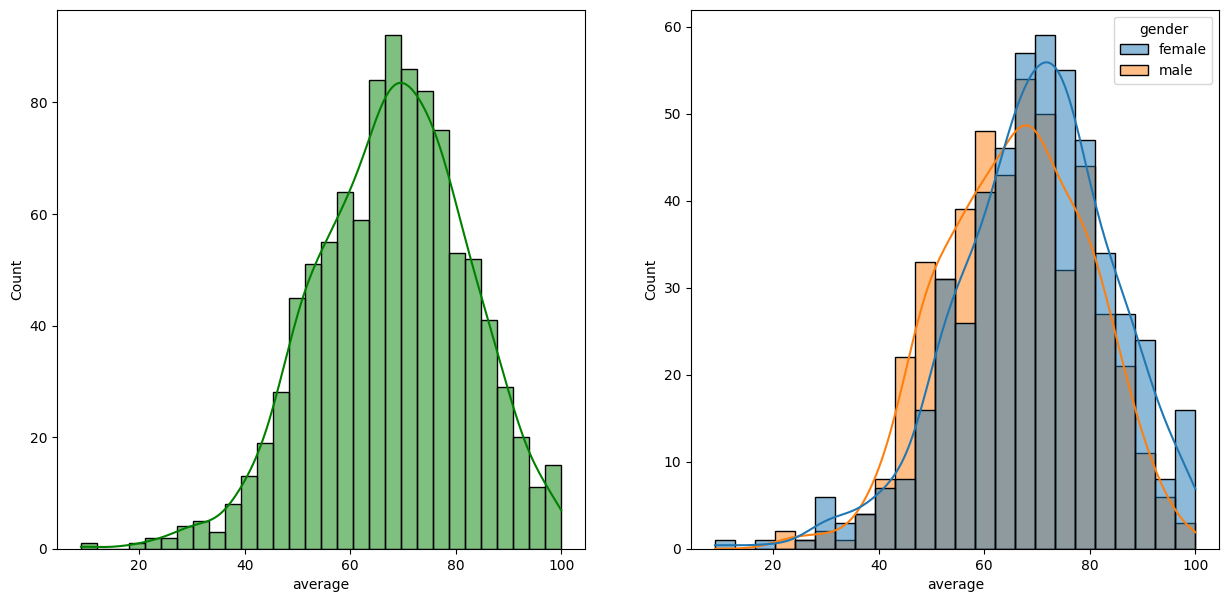

In [17]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(1,2,1)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(1,2,2)
sns.histplot(data=df, x='average',kde=True,hue='gender')
plt.show()

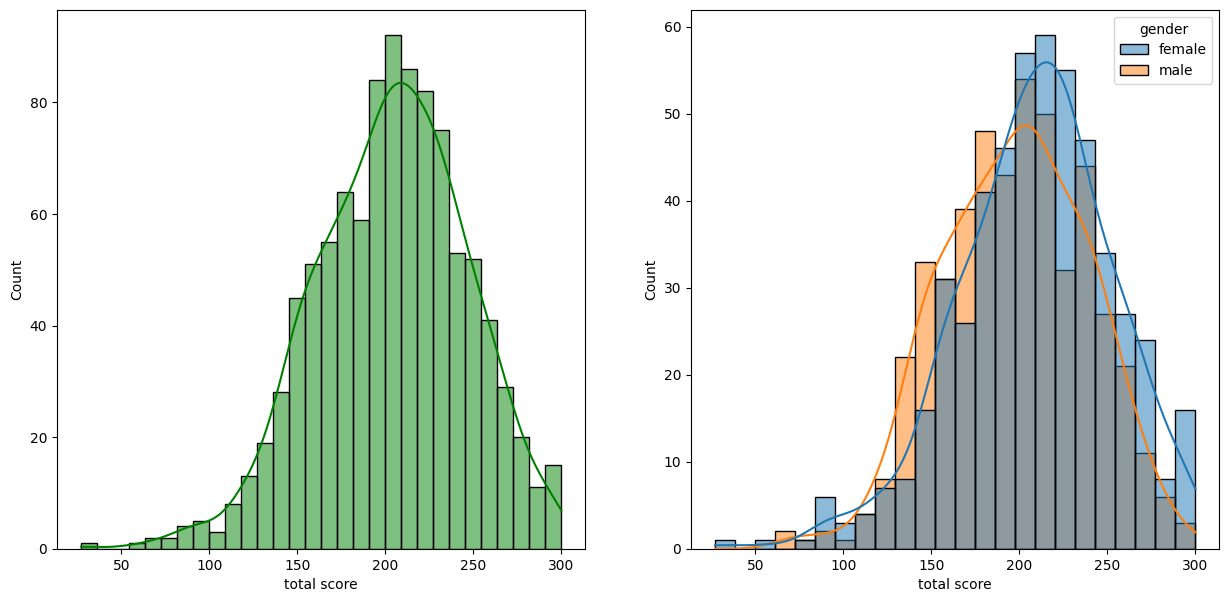

In [18]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(1,2,1)
sns.histplot(data=df,x='total score',bins=30,kde=True,color='g')
plt.subplot(1,2,2)
sns.histplot(data=df, x='total score',kde=True,hue='gender')
plt.show()

### Insights
- Female students tend to perform well than male students

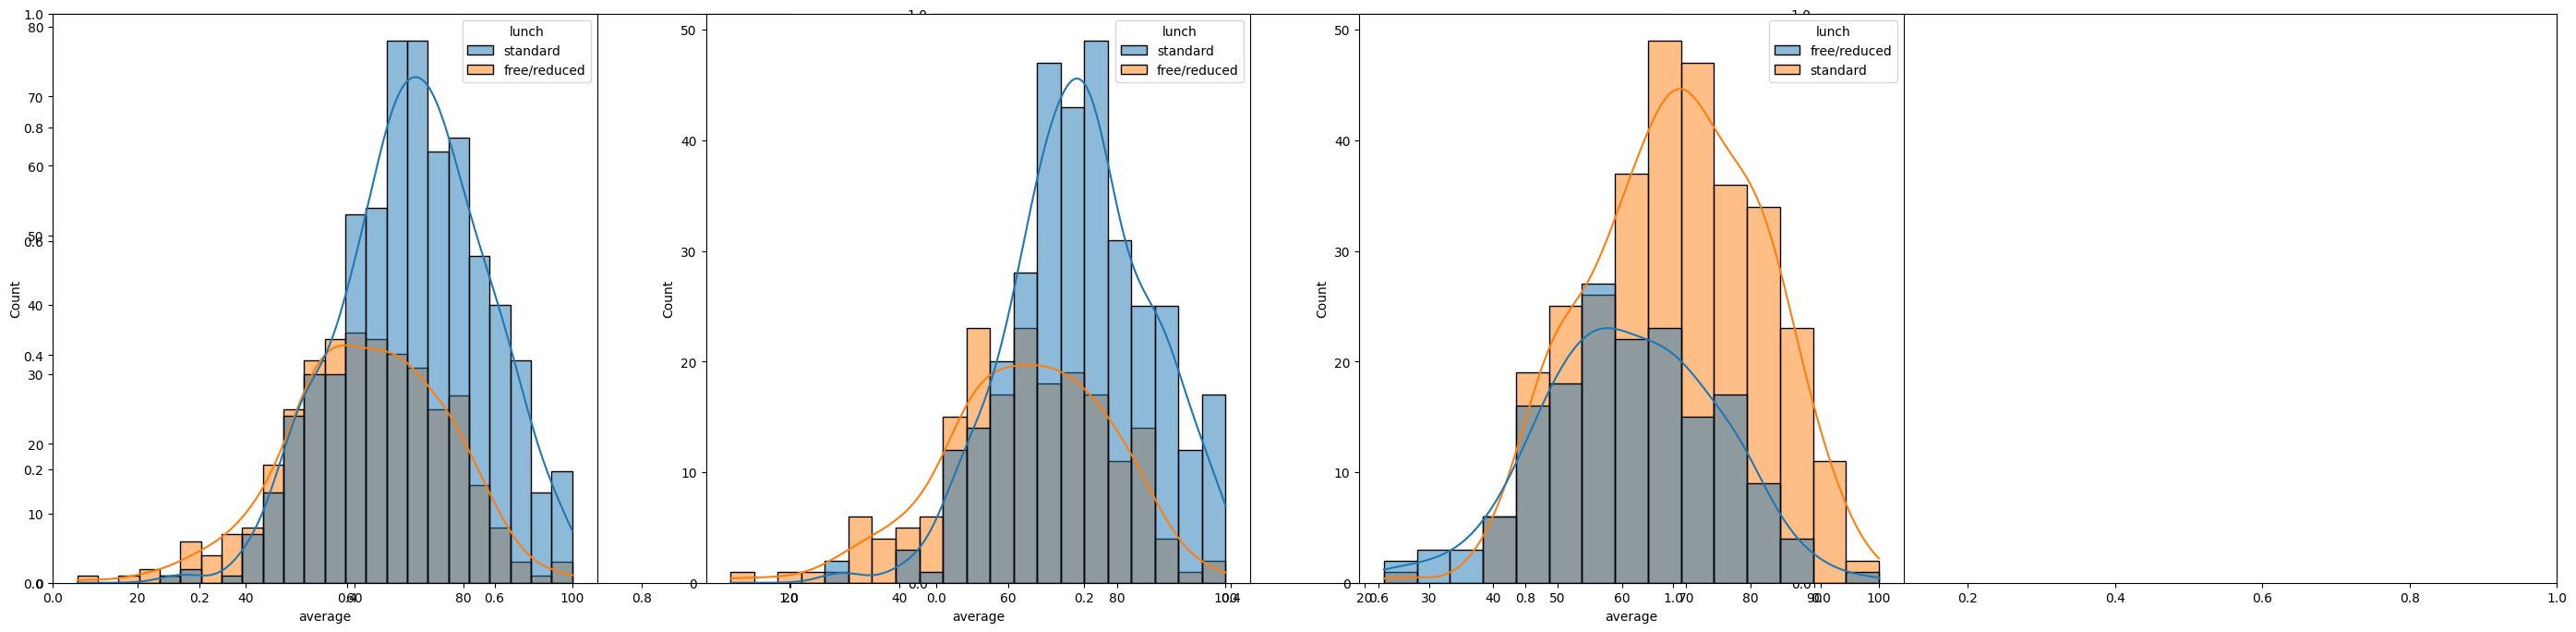

In [19]:
fig, axs = plt.subplots(1,3,figsize=(35,8))
plt.subplot(141)
sns.histplot(data=df,x='average', kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'], x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'], x='average',kde=True,hue='lunch')
plt.show()

### Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well regardless of gender.

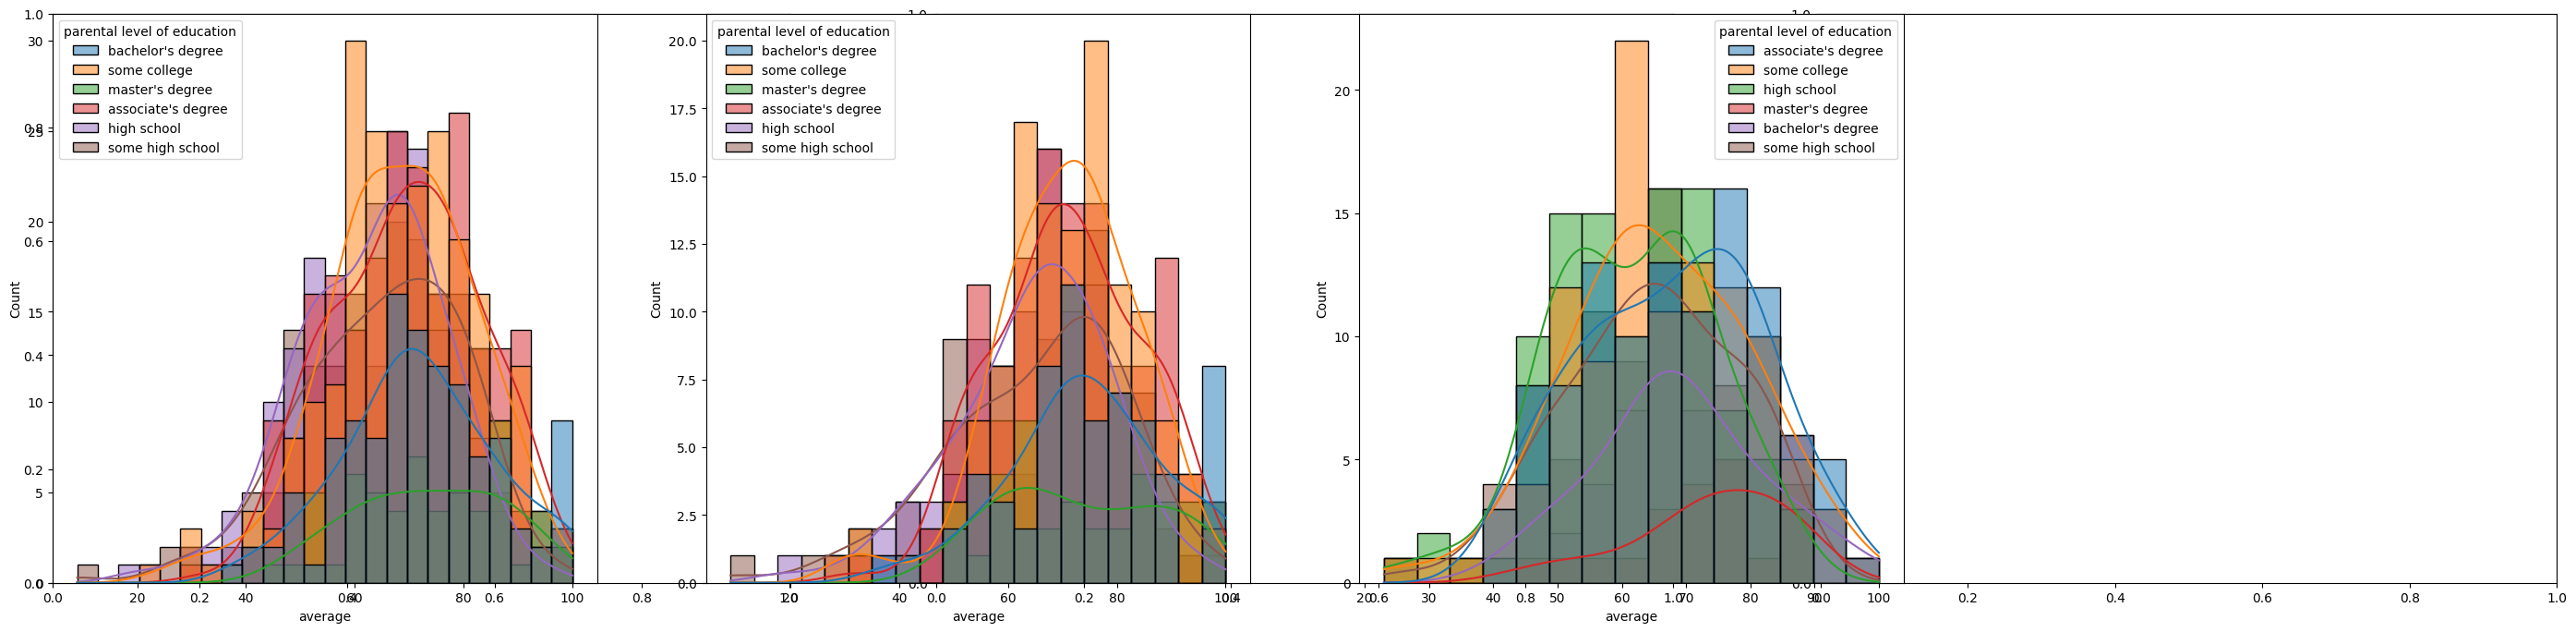

In [20]:
plt.subplots(1,3,figsize=(35,8))
plt.subplot(141)
ax=sns.histplot(data=df, x='average',kde=True, hue='parental level of education')

plt.subplot(142)
ax=sns.histplot(data=df[df.gender=='female'], x='average',kde=True,hue='parental level of education')

plt.subplot(143)
ax=sns.histplot(data=df[df.gender=='male'], x='average',kde=True,hue='parental level of education')

plt.show()

### Insights 
- In general parent's education doesn't help students perform well.
- As for female students in the second plot, there is no much effect on their performance.
- As for male students in the third plot, parent's whose education is of assosiate's degrees or master's degree their male child tend to perform well in exams.

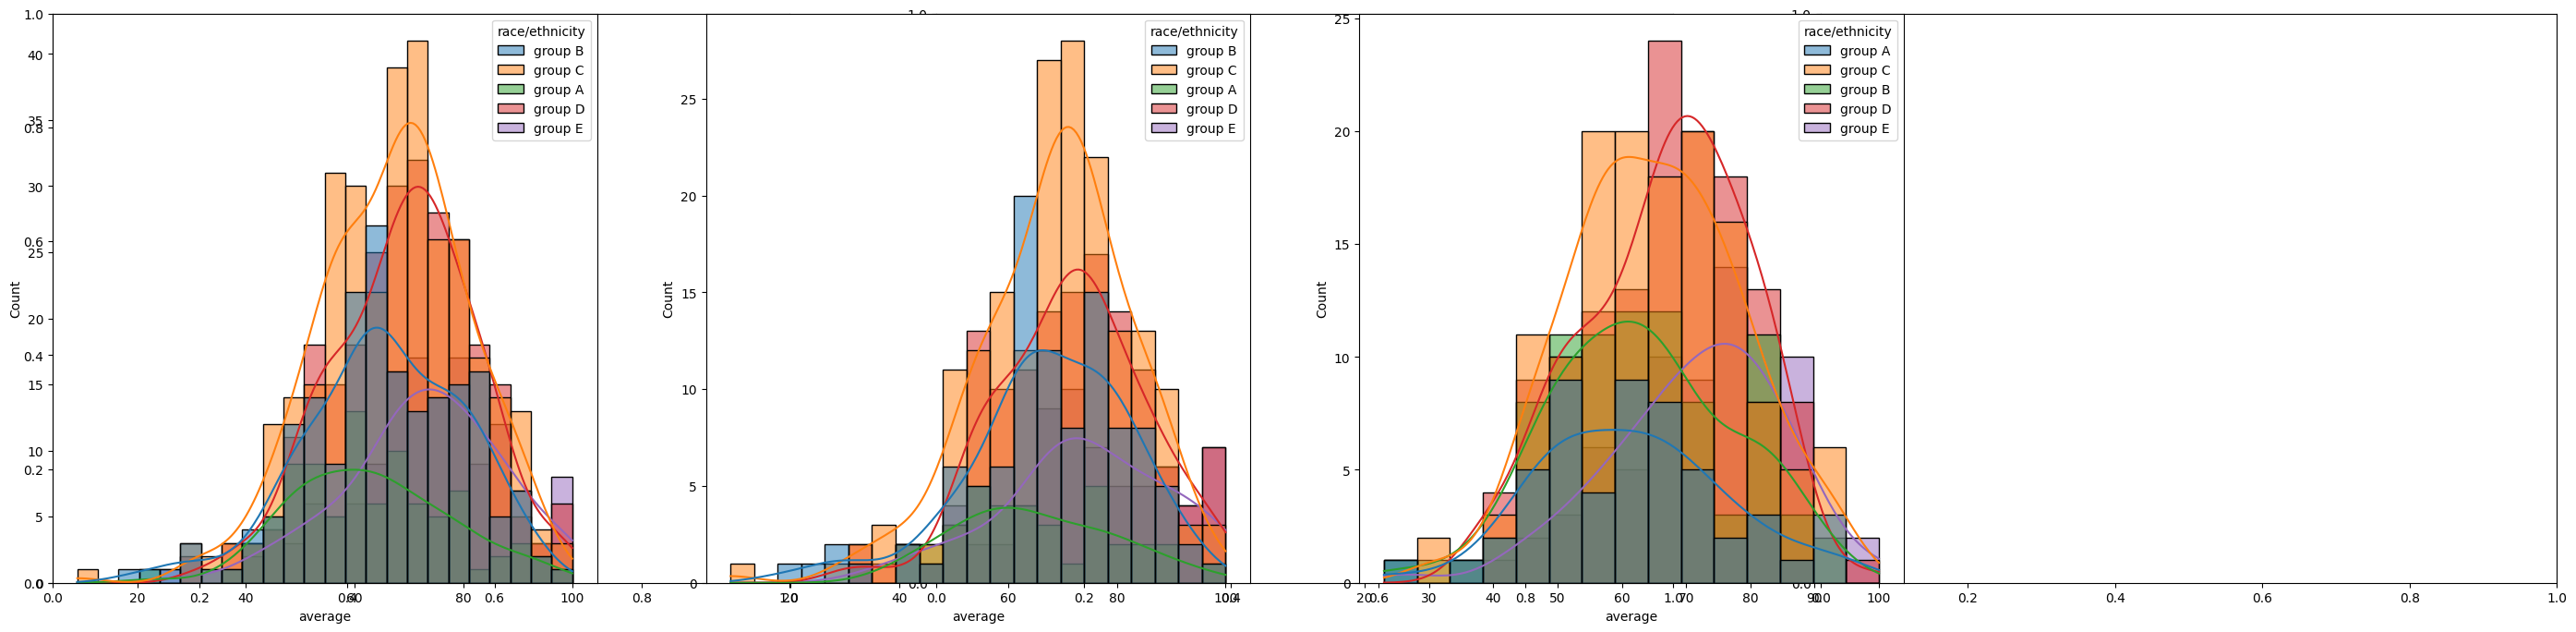

In [21]:
plt.subplots(1,3,figsize=(35,8))
plt.subplot(141)
ax=sns.histplot(data=df, x='average', kde=True, hue='race/ethnicity')

plt.subplot(142)
ax=sns.histplot(data=df[df.gender=='female'], x='average',kde=True, hue='race/ethnicity')

plt.subplot(143)
ax=sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='race/ethnicity')

plt.show()

### Insights 
- Students of group A and group B tend to perform poorly in exams.
- Students of group A and group B tend to perfrom poorly regardless of gender.

### 4.2 Maximum score of students in all three subjects

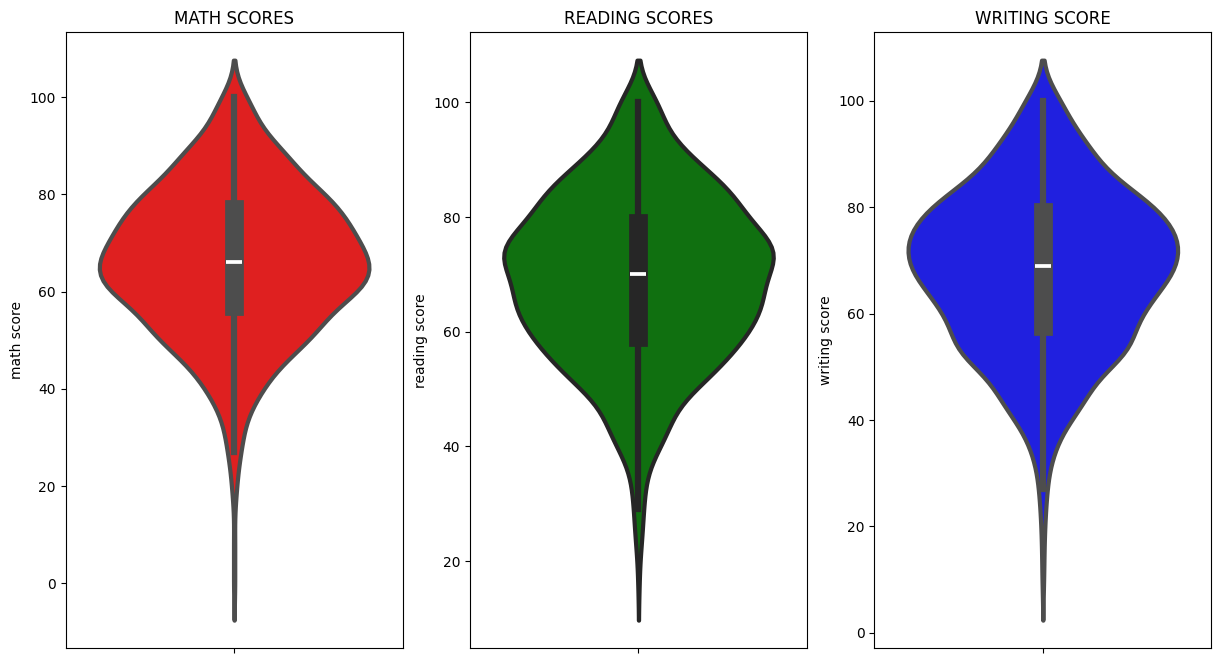

In [22]:
plt.figure(figsize=(20,8))
plt.subplot(1,4,1)
plt.title('MATH SCORES')
sns.violinplot(y='math score', data=df, color='red', linewidth=3)

plt.subplot(1,4,2)
plt.title("READING SCORES")
sns.violinplot(y='reading score', data=df, color='green', linewidth=3)

plt.subplot(1,4,3)
plt.title('WRITING SCORE')
sns.violinplot(y='writing score', data=df, color='blue', linewidth=3)

plt.show()

### Insights 
- From the above three plots, its clearly visible that most of the students score in between 60-80. 

### 4.3 Multivariate analysis using pieplot

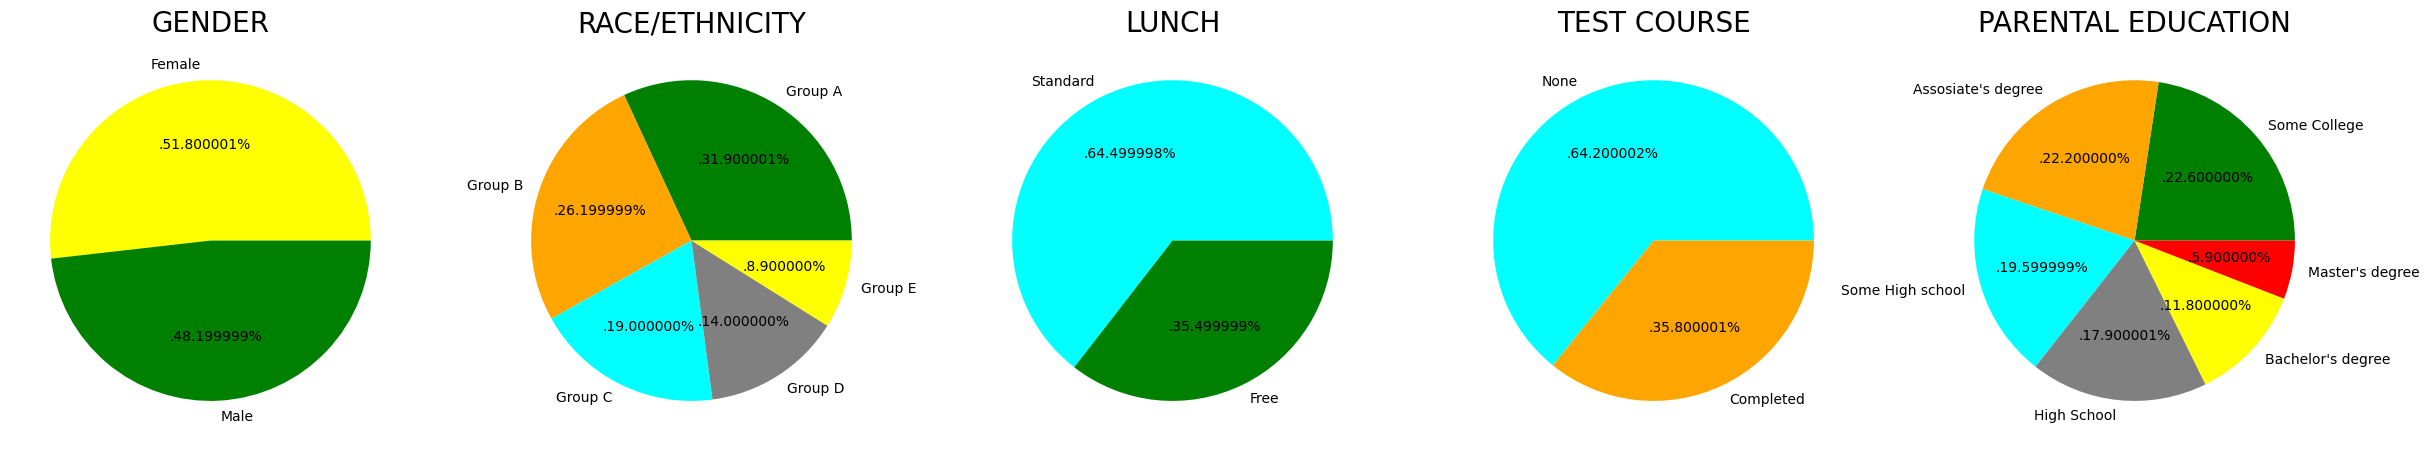

In [23]:
plt.rcParams['figure.figsize']= (30,12)

plt.subplot(1,5,1)
size= df['gender'].value_counts()
labels='Female','Male'
color=['yellow','green']

plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('GENDER', fontsize=20)
plt.axis('off')

plt.subplot(1,5,2)
size=df['race/ethnicity'].value_counts()
labels='Group A','Group B','Group C','Group D','Group E'
color=['green','orange','cyan','grey','yellow']

plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('RACE/ETHNICITY', fontsize=20)
plt.axis('off')

plt.subplot(1,5,3)
size= df['lunch'].value_counts()
labels='Standard','Free'
color=['cyan','green']

plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('LUNCH', fontsize=20)
plt.axis('off')

plt.subplot(1,5,4)
size= df['test preparation course'].value_counts()
labels='None','Completed'
color=['cyan','orange']

plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('TEST COURSE', fontsize=20)
plt.axis('off')

plt.subplot(1,5,5)
size=df['parental level of education'].value_counts()
labels=["Some College", "Assosiate's degree", "Some High school", "High School", "Bachelor's degree", "Master's degree"]
color=['green','orange','cyan','grey','yellow','red']

plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('PARENTAL EDUCATION', fontsize=20)
plt.axis('off')


plt.tight_layout
plt.grid()

plt.show()

### Insights 
- Number of male and female students is almost equal.
- Number of students are greatest in group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater, followed closely by "Associate's degree"

##  4.4 Feature Wise Visualization

### 4.4.1 Gender Column
- How is distribution of gender?
- Is gender impactful on student's perfromance?

## UNIVARIATE ANALYSIS (How is distribution of gender?)

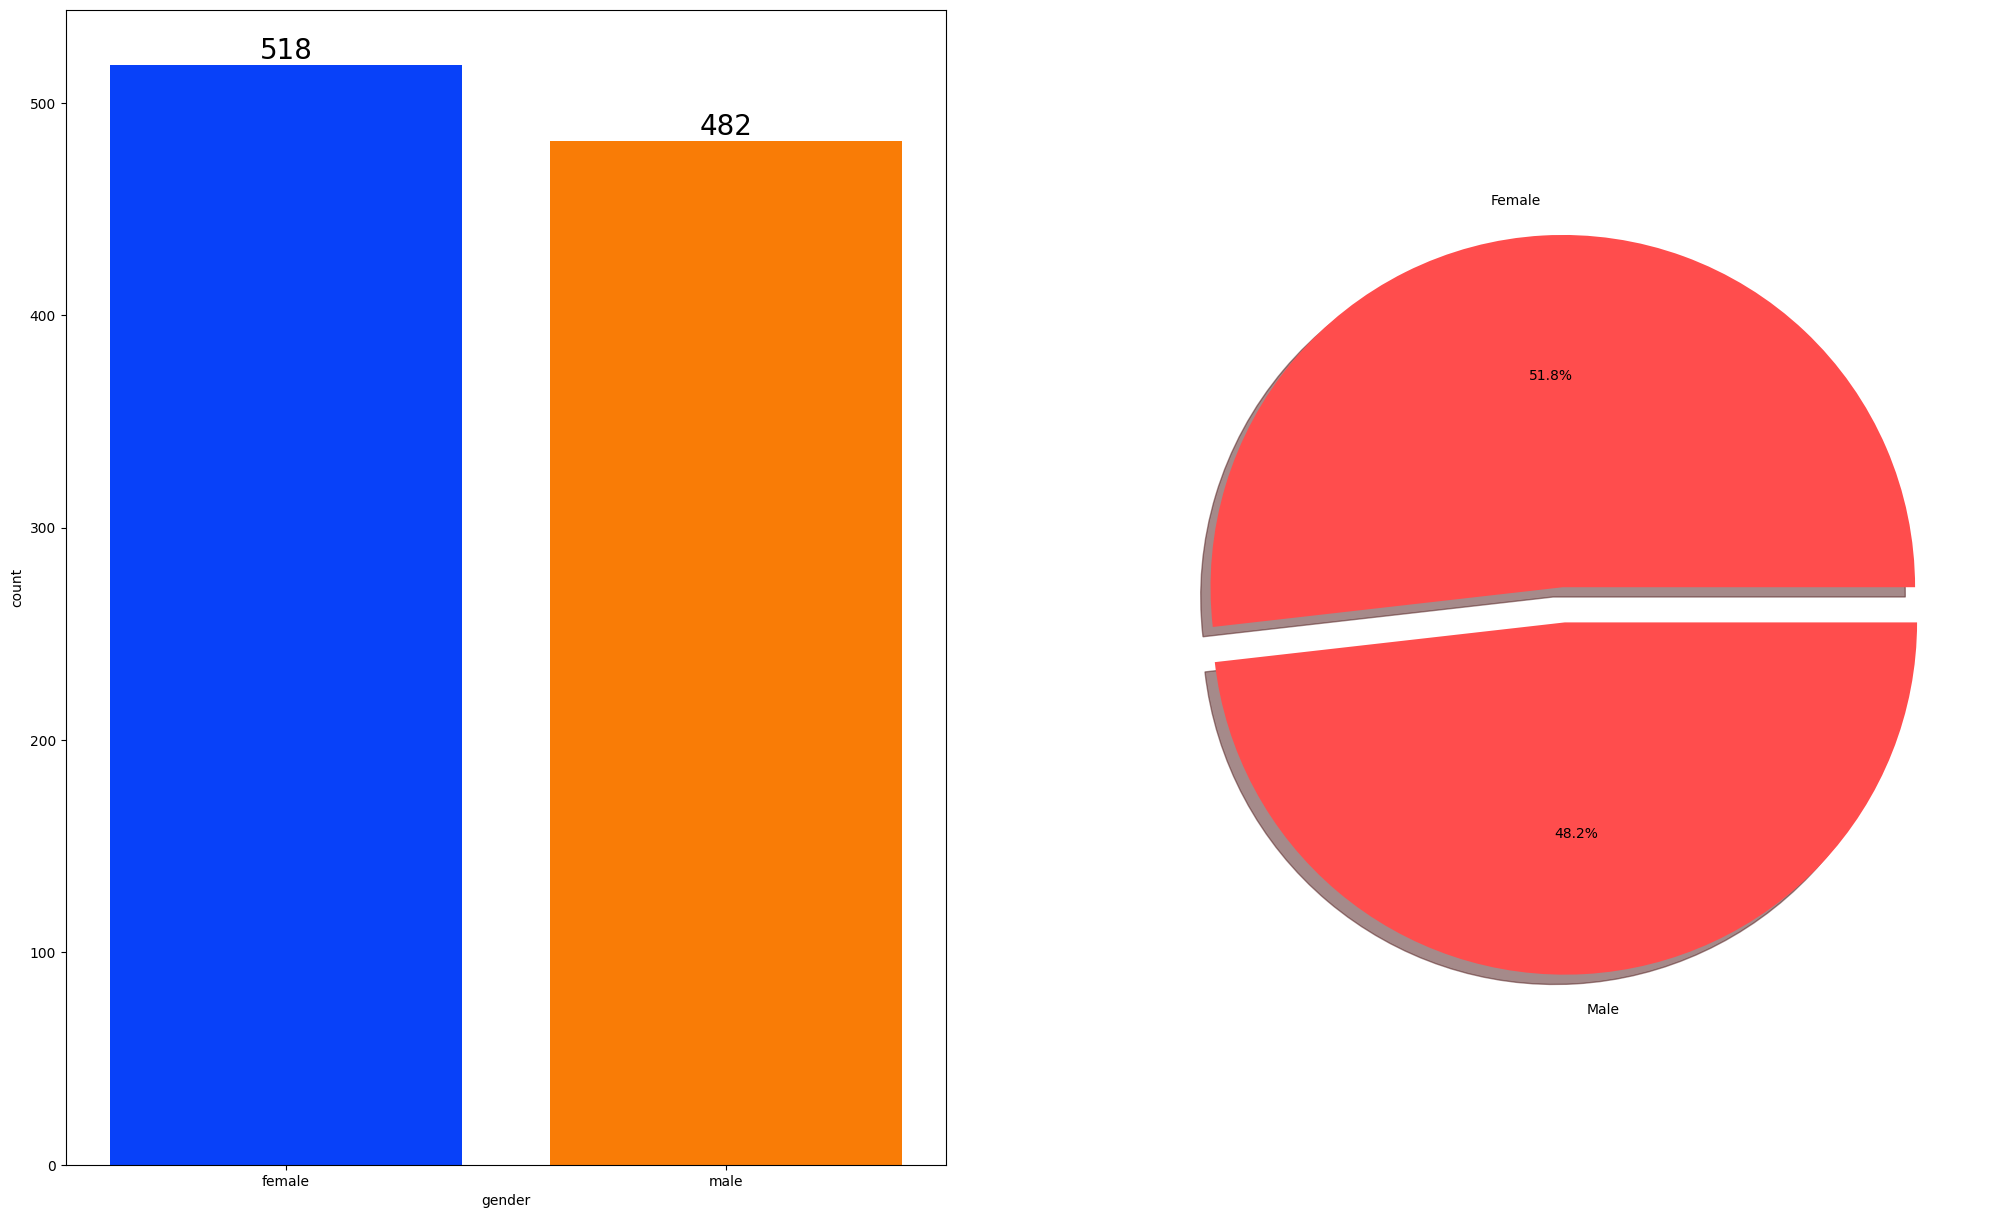

In [24]:
f, ax = plt.subplots(1,2,figsize=(25,15))
sns.countplot(x=df['gender'], data=df, palette='bright', ax=ax[0], saturation=0.95)

for container in ax[0].containers:
    ax[0].bar_label(container, color="black", size=20)

plt.pie(x=df["gender"].value_counts(), labels=['Female', 'Male'], explode=[0,0.1], autopct='%1.1f%%',shadow=True, colors=['#ff4d4d'])
plt.show()

### Insights
- Gender has balanced data with female students being 518(52%), and male students are 482(48%)

### BIVARIATE ANALYSIS (Is gender having any impact on student performance?)

In [25]:
gender_group = df.groupby('gender')

In [26]:
gender_group = df.groupby('gender')[df.select_dtypes(include='number').columns].mean()
print(gender_group)

        math score  reading score  writing score  total score    average
gender                                                                  
female   63.633205      72.608108      72.467181   208.708494  69.569498
male     68.728216      65.473029      63.311203   197.512448  65.837483


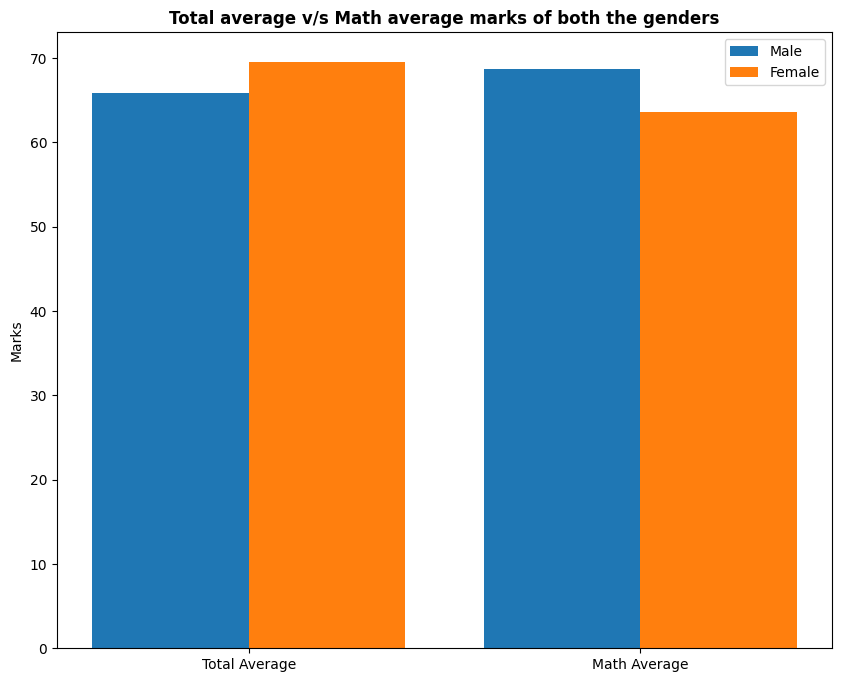

In [27]:
plt.figure(figsize=(10,8))

x= ['Total Average', 'Math Average']

female_scores=[gender_group['average'][0], gender_group['math score'][0]]
male_scores= [gender_group['average'][1], gender_group['math score'][1]]

x_axis = np.arange(len(x))

plt.bar(x_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(x_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(x_axis, x)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

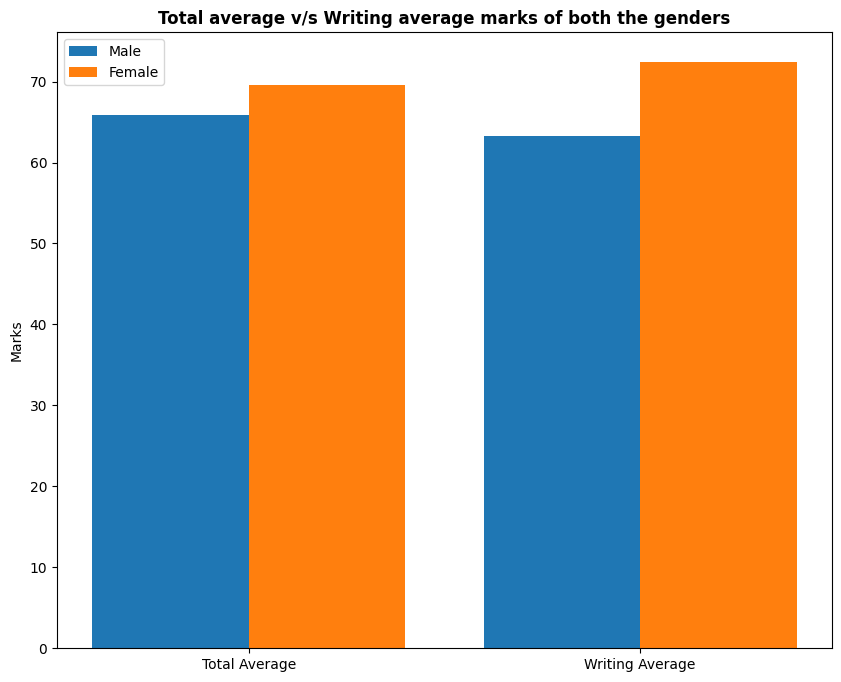

In [28]:
plt.figure(figsize=(10,8))

x= ['Total Average', 'Writing Average']

female_scores=[gender_group['average'][0], gender_group['writing score'][0]]
male_scores= [gender_group['average'][1], gender_group['writing score'][1]]

x_axis = np.arange(len(x))

plt.bar(x_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(x_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(x_axis, x)
plt.ylabel("Marks")
plt.title("Total average v/s Writing average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

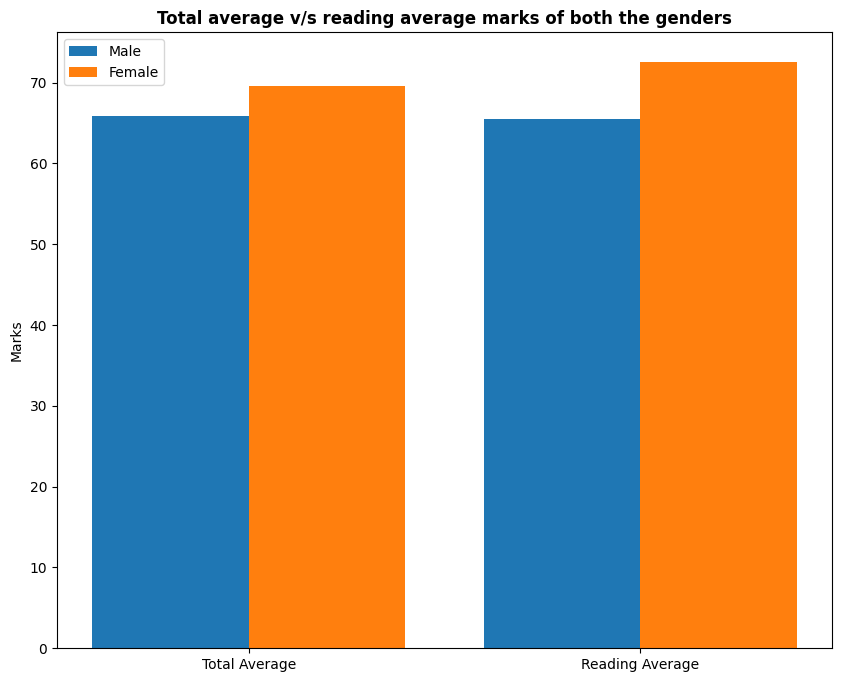

In [29]:
plt.figure(figsize=(10,8))

x= ['Total Average', 'Reading Average']

female_scores=[gender_group['average'][0], gender_group['reading score'][0]]
male_scores= [gender_group['average'][1], gender_group['reading score'][1]]

x_axis = np.arange(len(x))

plt.bar(x_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(x_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(x_axis, x)
plt.ylabel("Marks")
plt.title("Total average v/s reading average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

### Insights
- In general, girls perform better than boys.
- Boys do better in Math whereas girls so better in both writing and reading.

### 4.4.2 RACE/ETHNICITY COLUMN
- How is group wise distribution?
- Is race/ethnicity impactful on a student's performance?

### UNIVARIATE ANALYSIS (How is group wise distribution?)

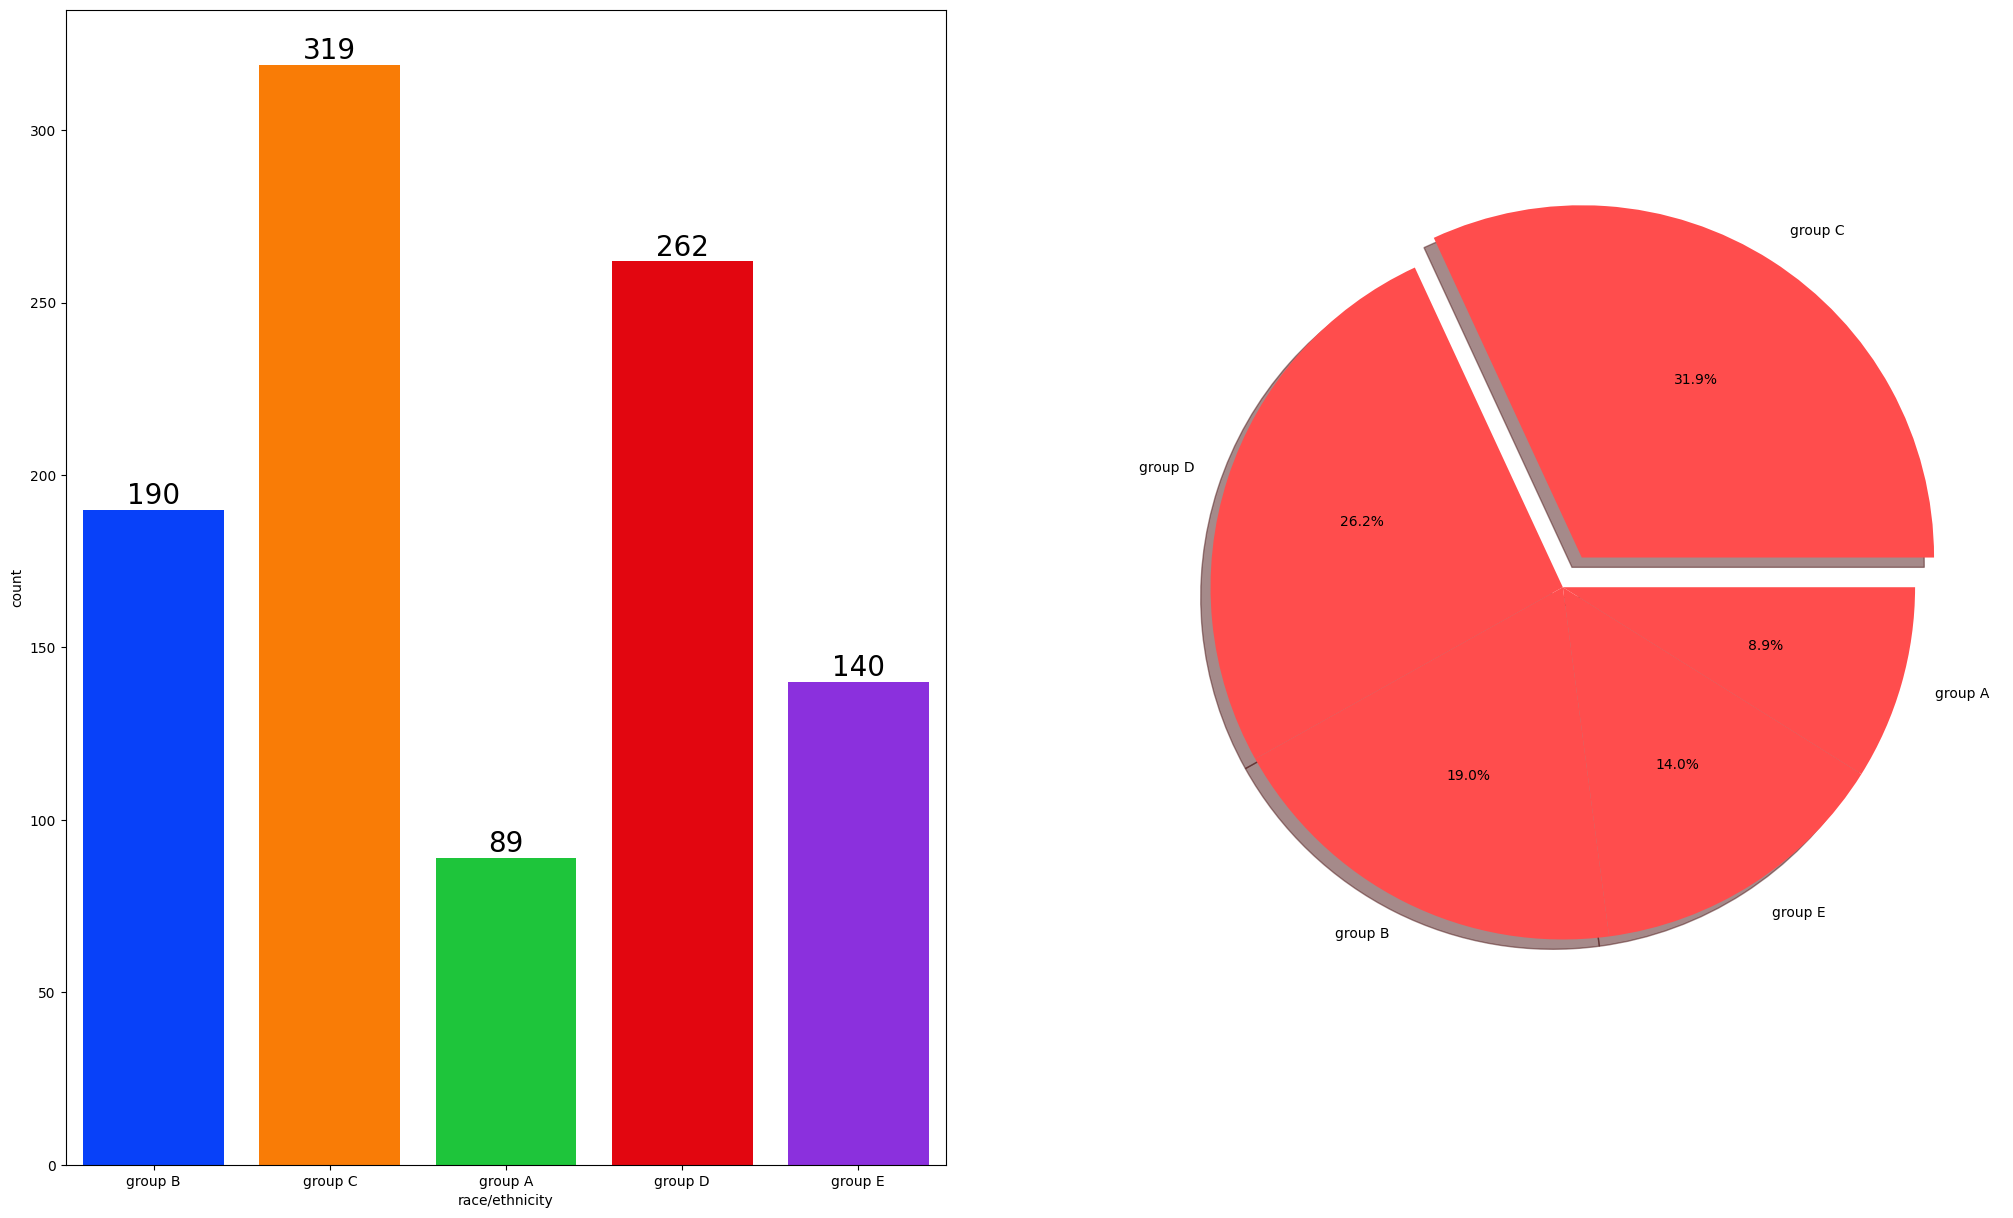

In [30]:
f, ax = plt.subplots(1,2,figsize=(25,15))
sns.countplot(x=df['race/ethnicity'], data=df, palette='bright', ax=ax[0], saturation=0.95)

for container in ax[0].containers:
    ax[0].bar_label(container, color="black", size=20)

plt.pie(x=df['race/ethnicity'].value_counts(), labels=df['race/ethnicity'].value_counts().index, explode=[0.1,0,0,0,0], autopct='%1.1f%%',shadow=True, colors=['#ff4d4d'])
plt.show()

### Insights 
- Group C students are the most, followed by group D while Group A are the least.

### BIVARIATE ANALYSIS (Is Race/Ethnicity impactful on a student's performance?)

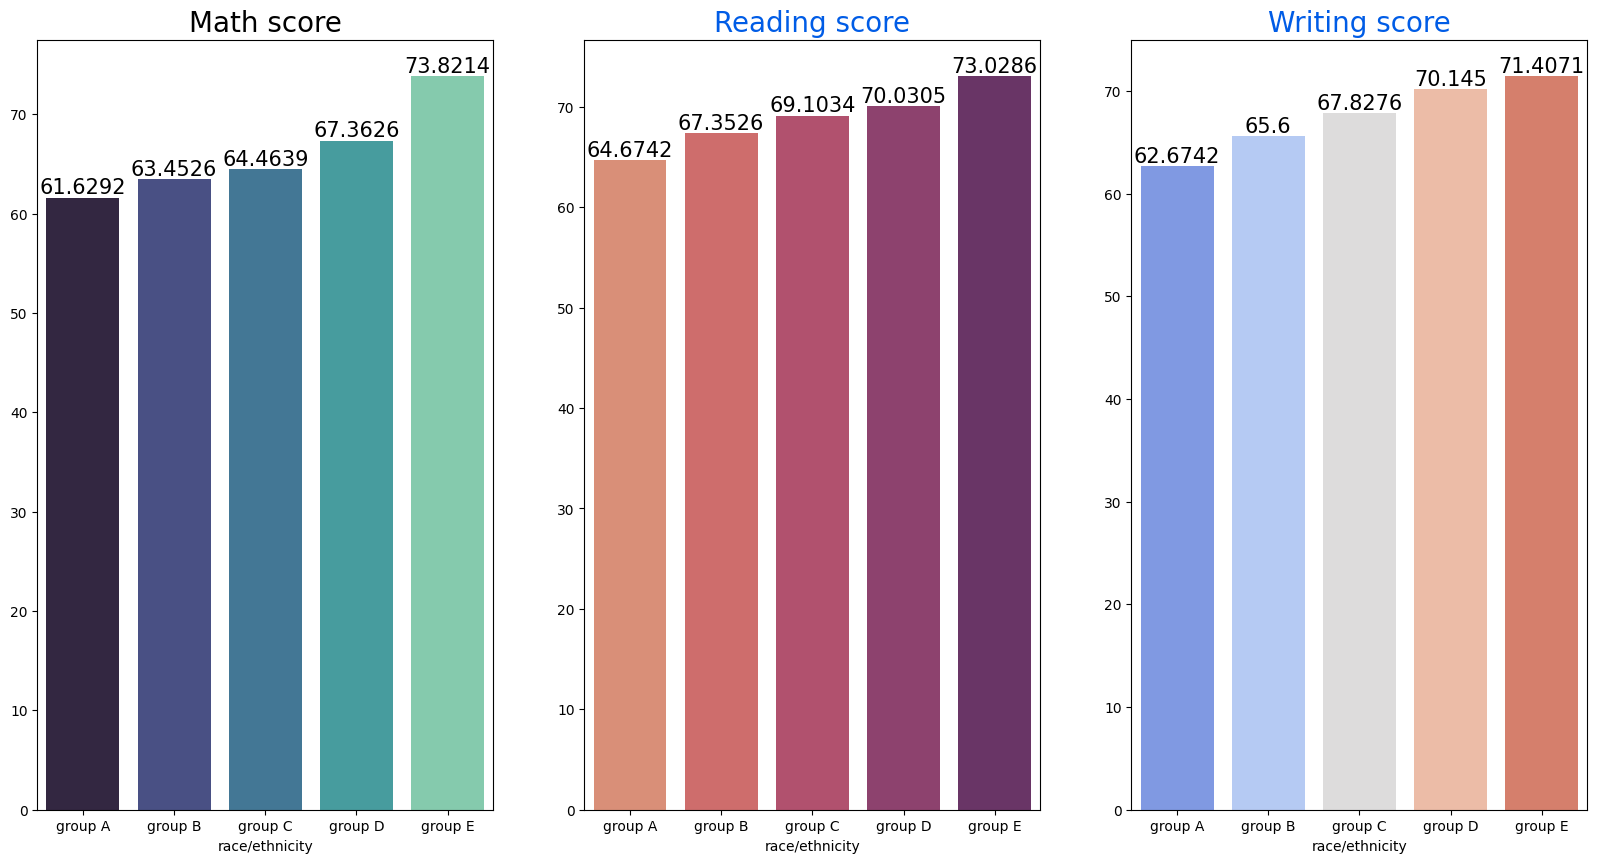

In [31]:
group_data2= df.groupby('race/ethnicity')

f, ax = plt.subplots(1,3,figsize= (20,10))
sns.barplot(x=group_data2['math score'].mean().index, y=group_data2['math score'].mean().values, palette='mako', ax=ax[0])
ax[0].set_title('Math score', color='black', size=20)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)

sns.barplot(x=group_data2['reading score'].mean().index, y=group_data2['reading score'].mean().values, palette="flare",ax=ax[1])
ax[1].set_title('Reading score', color='#005ce6', size=20)


for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=15)

sns.barplot(x=group_data2['writing score'].mean().index, y=group_data2['writing score'].mean().values, palette="coolwarm",ax=ax[2])
ax[2].set_title('Writing score', color='#005ce6', size=20)

for container in ax[2].containers:
    ax[2].bar_label(container, color='black', size=15)

### Insights
- Group E students score the highest marks
- Group A score the lowest marks.
- Students from a lower socio-economic status have a lower average in all course subjects

### 4.4.3 PARENTAL LEVEL OF EDUCATION
- What is the educational background of student's parents?
- Is parental education impactful on student's performance?


UNIVARIATE ANALYSIS (What is the educational background of student's parents?)

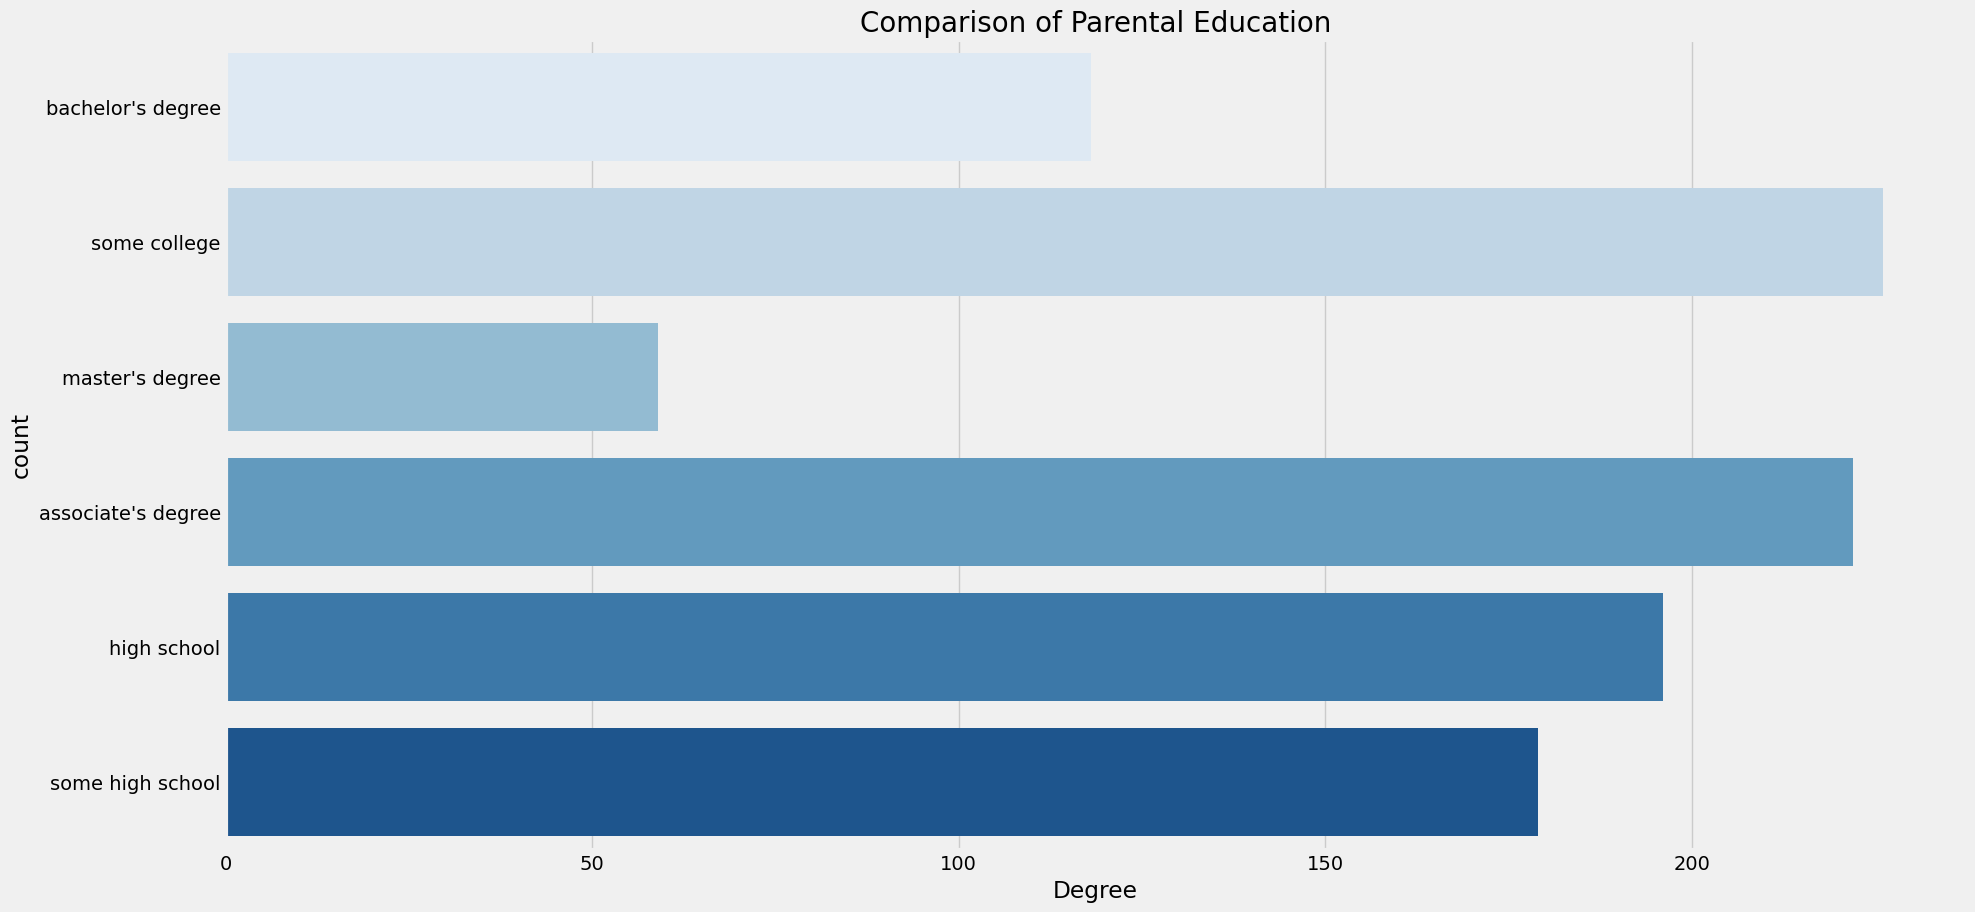

In [32]:
plt.rcParams['figure.figsize'] = (20,10)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental level of education'], palette='Blues')
plt.title('Comparison of Parental Education', fontweight=30, fontsize=20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()


### Insights
- Majority of students have parents with the Some College educational background

### BIVARIATE ANALYSIS (Is parental education impactful on student performance?)

In [33]:
print(df.groupby('parental level of education').first
())

                             gender race/ethnicity         lunch  \
parental level of education                                        
associate's degree             male        group A  free/reduced   
bachelor's degree            female        group B      standard   
high school                    male        group D  free/reduced   
master's degree              female        group B      standard   
some college                 female        group C      standard   
some high school             female        group C      standard   

                            test preparation course  math score  \
parental level of education                                       
associate's degree                             none          47   
bachelor's degree                              none          72   
high school                               completed          64   
master's degree                                none          90   
some college                              completed  

In [34]:
numeric_cols=df.select_dtypes(include='number')

# #df.dtypes
df.groupby('parental level of education')[numeric_cols].mean().plot(kind='barh', figsize=(20,15))

# non_numeric_cols = df.select_dtypes(exclude='number').columns

# agg_funcs = {col: 'mean' for col in numeric_cols}
# agg_funcs.update({col: 'first' for col in non_numeric_cols})

# # grouped_df= df.groupby('parental level of education').agg(agg_funcs)

# # grouped_df[numeric_cols].plot(kind='barh', figsize=(20,10))

# # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad= 0.)
# # plt.show()



TypeError: unhashable type: 'DataFrame'

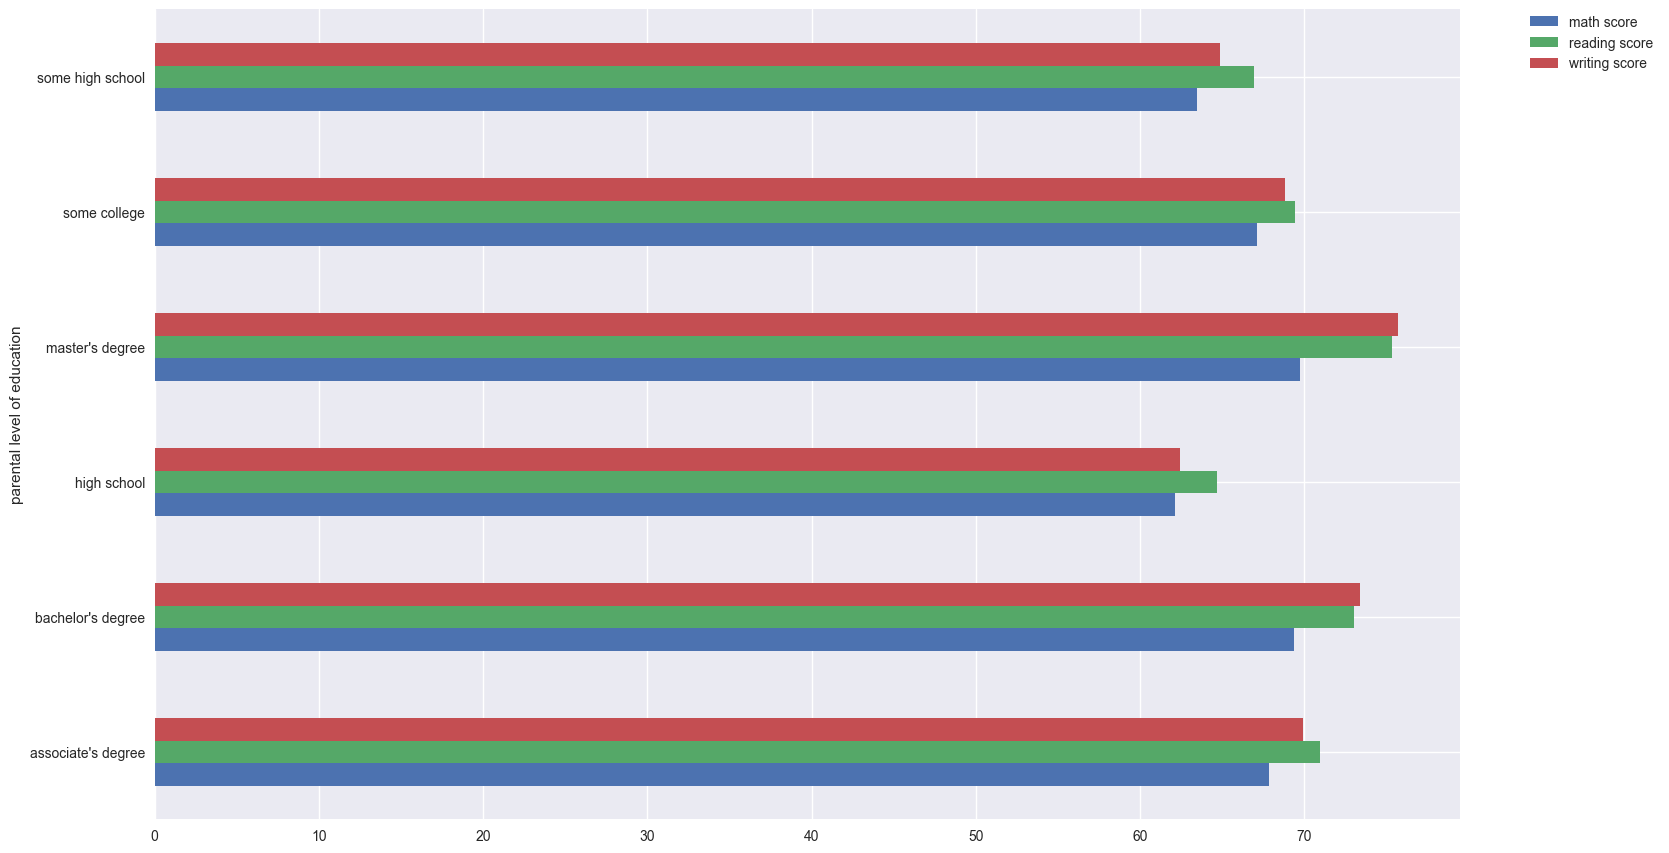

In [48]:
#specifying exactly which columns to include
df.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean().plot(kind='barh', figsize=(15,10))
plt.legend(bbox_to_anchor=(1.05,1), loc=2, borderaxespad=0.)
plt.show()

### Insights
Parental education does have an impact on a kids performance, as seen from the graph, student's from homes with master's degrees (the highest level of education) average the highest compared to the rest.

### 4.4.4 Lunch COLUMN
- Which type of lunch is most common among students?
- What is the effect of the lunch type on test results?

### UNIVARIATE ANALYSIS (Which type of Lunch is most common among students?)

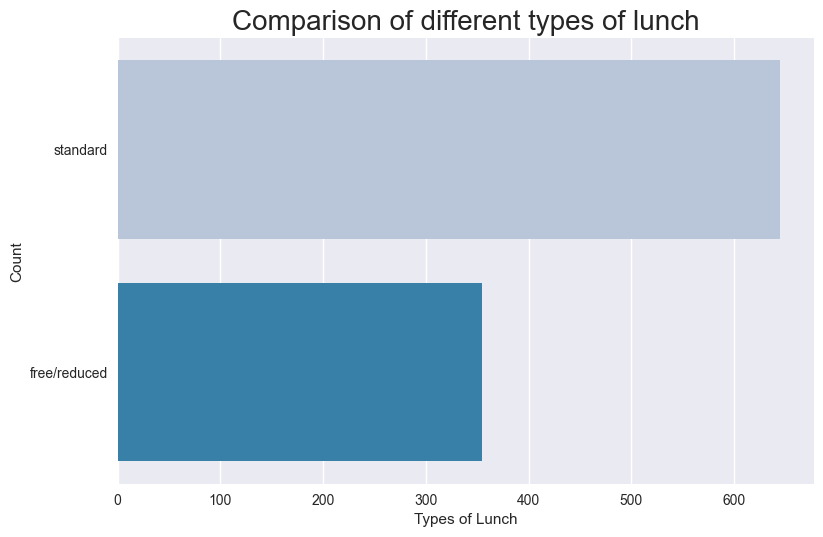

In [36]:
plt.rcParams['figure.figsize'] =  (15,9)
plt.style.use('seaborn-v0_8')
# encountered an error with the code above seaborn-talk as a style, learnt that it's invalid, had to find and learn of new styles
sns.countplot(df['lunch'], palette="PuBu")

plt.title('Comparison of different types of lunch', fontweight=30, fontsize=20)
plt.xlabel("Types of Lunch")
plt.ylabel('Count')
plt.show()

### Insights
- Students being served Standard lunch was more than free lunch


### BIVARIATE ANALYSIS (Is lunch type intake has any impact on student's performance?)

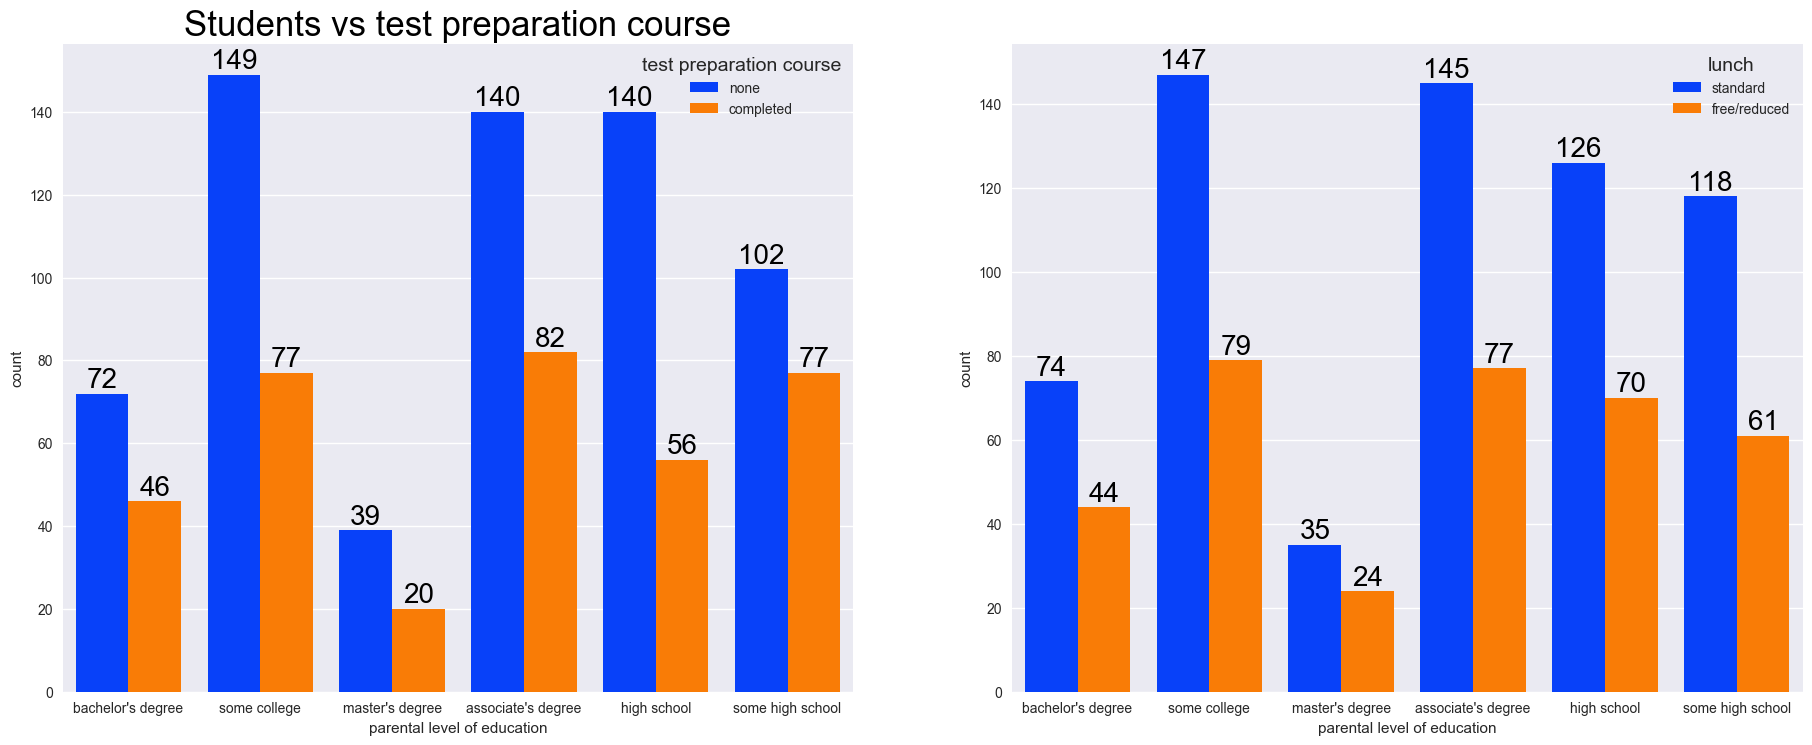

In [37]:
f, ax= plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental level of education'],data=df, palette='bright', hue='test preparation course', saturation=0.95, ax=ax[0])
ax[0].set_title('Students vs test preparation course', color='black', size=25)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

sns.countplot(x=df['parental level of education'], data=df, palette='bright', hue='lunch', saturation=0.95, ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=20)


### Insights
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

## 4.4.5 TEST PREPARATION COURSE COLUMN
- Which type of lunch is most common amoung students
- Is test preparation course has any impact on student's performance

### BIVARIATE ANALYSIS (Is test preparation course has any impact on student's performance?)

In [40]:
df.shape

(1000, 10)

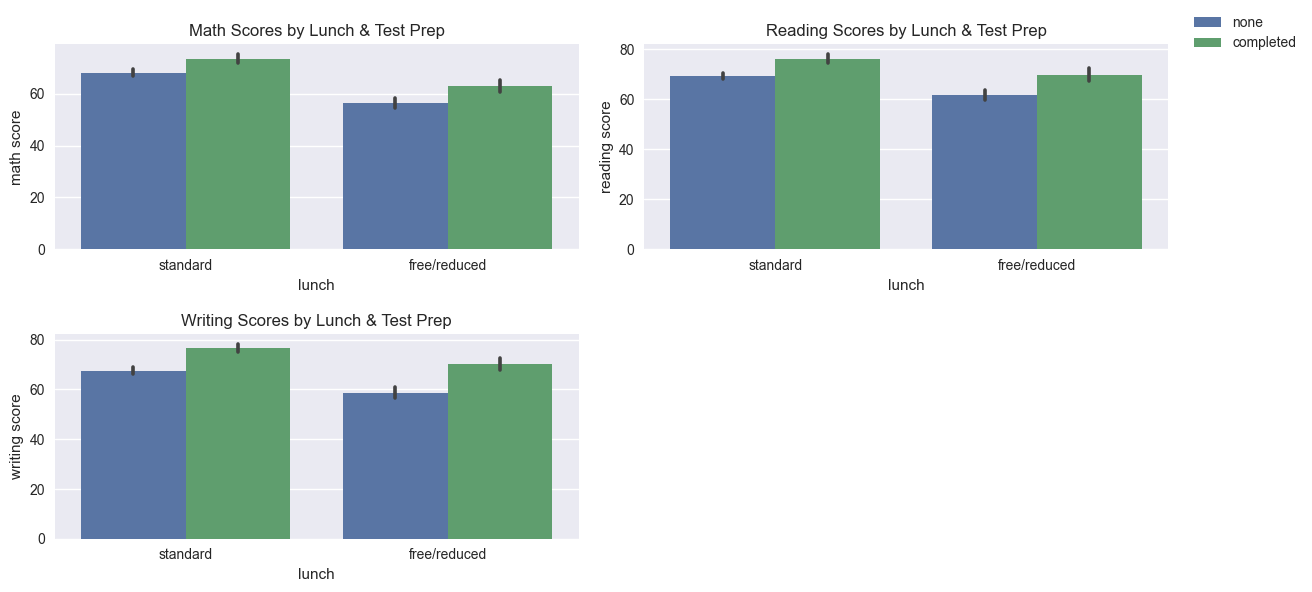

In [47]:
plt.figure(figsize=(12,6))
#creating this list to remove overlapping legends and store them there then put them aside
handles = []
labels = []

plt.subplot(2,2,1)
plot1= sns.barplot(x=df['lunch'], y=df['math score'], hue=df['test preparation course'])
plt.title('Math Scores by Lunch & Test Prep')
handles, labels = plot1.get_legend_handles_labels()

plt.subplot(2,2,2)
sns.barplot(x=df['lunch'], y=df['reading score'], hue=df['test preparation course'])
plt.title('Reading Scores by Lunch & Test Prep')

plt.subplot(2,2,3)
sns.barplot(x=df['lunch'], y=df['writing score'], hue=df['test preparation course'])
plt.title('Writing Scores by Lunch & Test Prep')

#removing legends from individual subplots
plt.subplot(2,2,1).get_legend().remove()
plt.subplot(2,2,2).get_legend().remove()
plt.subplot(2,2,3).get_legend().remove()

#adding single legend to the figure
plt.figlegend(handles=handles, labels=labels, loc='upper right', bbox_to_anchor=(1.1, 1))

plt.tight_layout()


### Insight
- Students who completed the test preparation courses do better in all the scores.

## 4.4.6 CHECKING FOR OUTLIERS

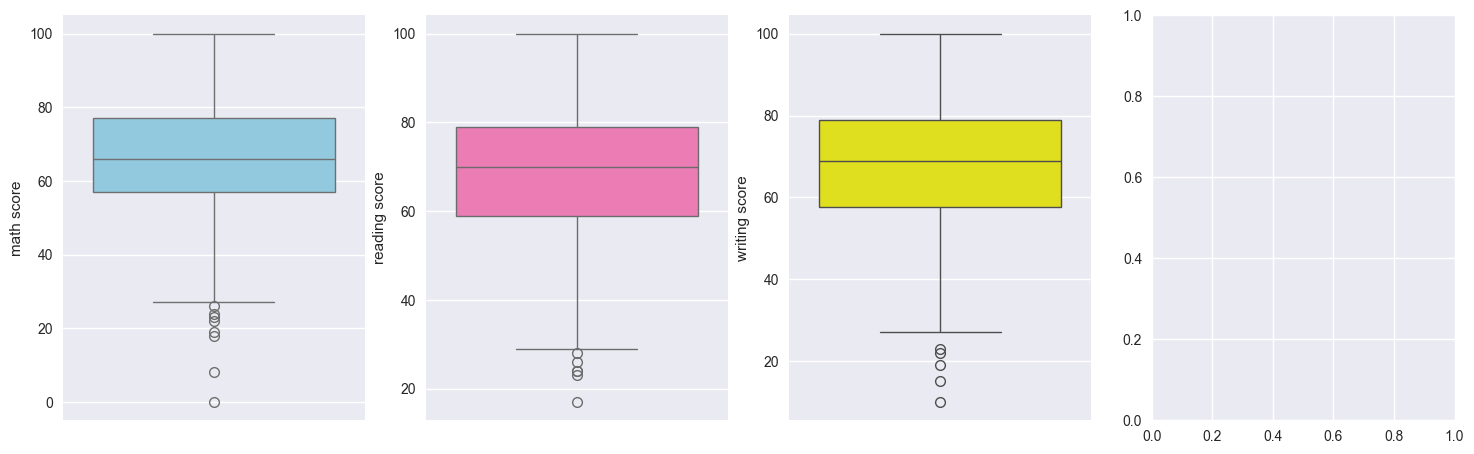

In [51]:
plt.subplots(1,4, figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'], color='skyblue')

plt.subplot(142)
sns.boxplot(df['reading score'], color='hotpink')

plt.subplot(143)
sns.boxplot(df['writing score'], color='yellow')

plt.subplot(144)
sns.boxplot(df=['average'], color='lightgreen')

plt.show()

### 4.4.7 Multivariate Analysis Using Pairplot

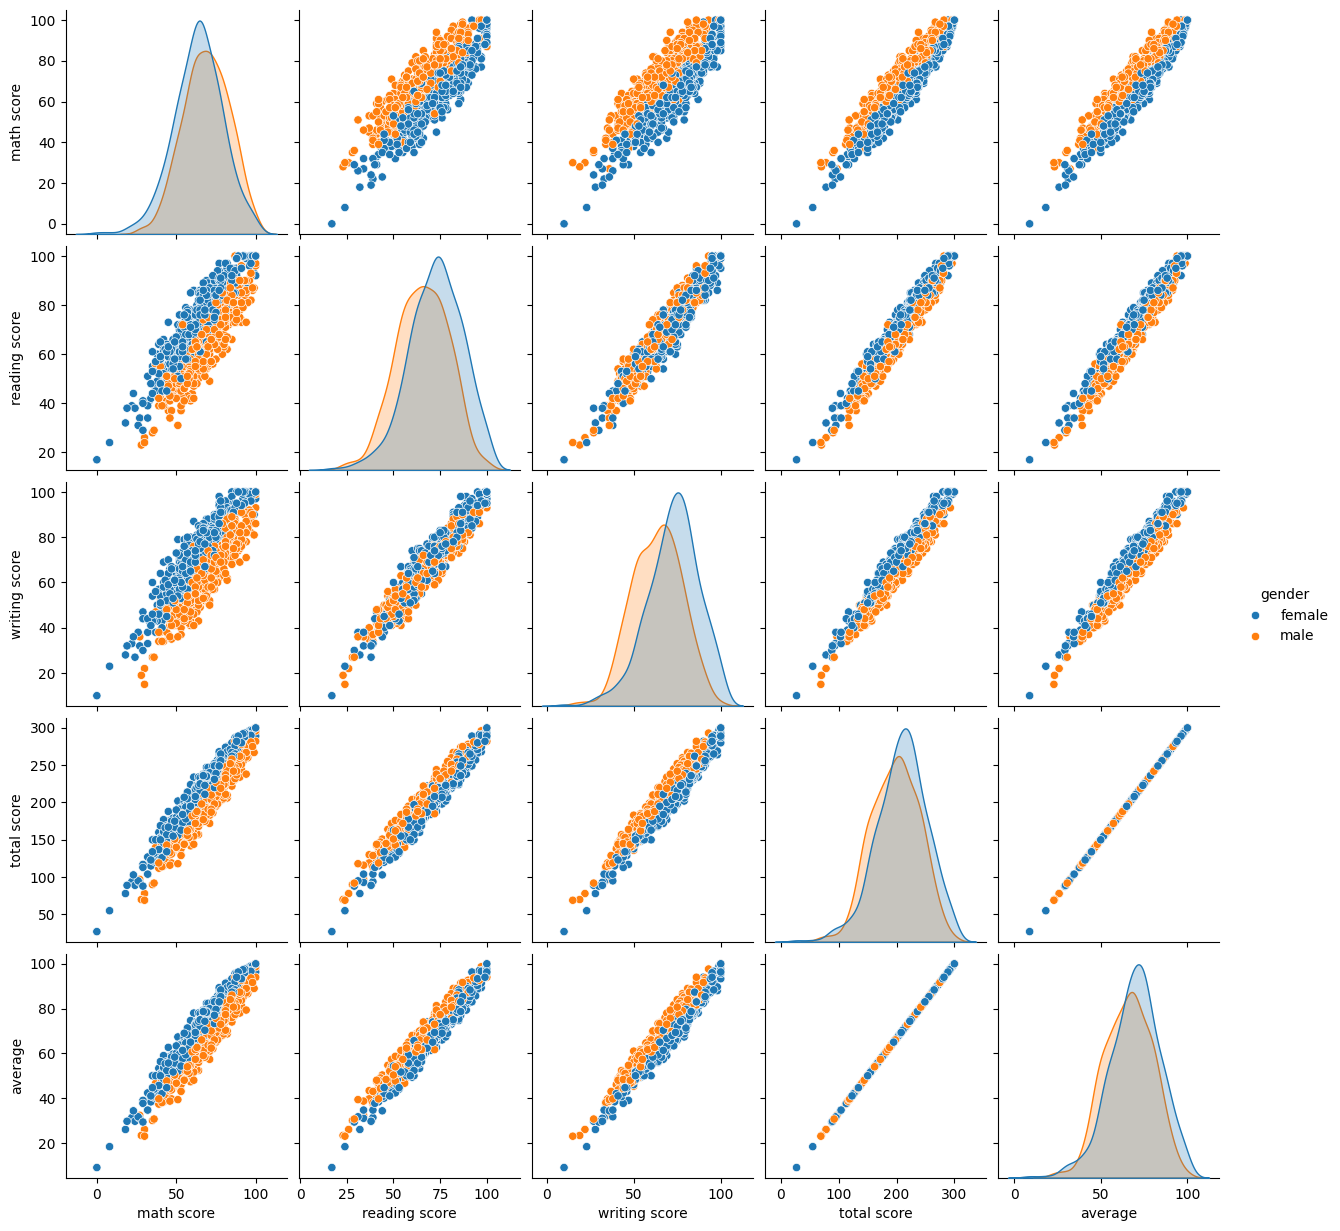

In [9]:
sns.pairplot(df,hue='gender')
plt.show()

Insights
- From the above plot it's clear that all the scores increase, linearly with each other.

### 5. CONCLUSIONS


- Student's Performance is related with lunch, race, parental level education.
- Girls lead in pass percentage and are also top scorers.
- Student performance is not much related with the test preparation course.
- Finishing preparatation course is also beneficial.